<div style="
    padding:25px;
    text-align:center;
    border-radius:18px;
    background:linear-gradient(135deg,#F8FFF4,#E8F5E9,#C8E6C9);
    box-shadow:0 8px 20px rgba(0,0,0,0.15);
    border:3px solid #4CAF50;">

<h1 style="
    margin:0;
    color:#212121;
    font-size:40px;
    font-family:Georgia,serif;
    font-weight:bold;
    text-shadow:1px 1px 3px rgba(255,255,255,0.6);">
🛒 Online Retail Customer Segmentation using Clustering
</h1>

</div>

<h3 align="center" style="font-size: 35px; color: #800080; font-family: Georgia;">
    <span style="color: #008080;"> Author:</span> 
    <span style="color: black;">AGRIM AGARWAL .📄🖋️</span>
</h3>

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRnufMPjGd23ekLUqg-AGEHfQhit0AsMsQXZxIdGPlcNg&s" style='width: 1000px; height: 450px;'>

In [201]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import PowerTransformer

In [202]:
df=pd.read_excel(r"C:\Users\hp\Downloads\Online Retail.xlsx")

In [203]:
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
101806,544931,10133,COLOURING PENCILS BROWN TUBE,10,2011-02-24 18:59:00,0.85,13501.0,Switzerland
249196,558888,22403,MAGNETS PACK OF 4 VINTAGE LABELS,2,2011-07-04 15:29:00,0.39,14056.0,United Kingdom
46561,540355,22080,RIBBON REEL POLKADOTS,1,2011-01-06 15:11:00,4.21,NaN,United Kingdom
42485,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313.0,United Kingdom
243294,558442,23299,FOOD COVER WITH BEADS SET 2,1,2011-06-29 13:10:00,3.75,15537.0,United Kingdom


In [204]:
print("INFORMATION:- \n",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
INFORMATION:- 
 None


In [205]:
print("NULL VALUES:-\n",df.isnull().sum())

NULL VALUES:-
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [206]:
print("DUPLICATED:-",df.duplicated().sum())

DUPLICATED:- 5268


In [207]:
##drop duplicated value
df.drop_duplicates(inplace=True)

In [208]:
##cheak if duplicated is still remain or not
print("DUPLICATED:-",df.duplicated().sum())

DUPLICATED:- 0


In [209]:
# Count null values
null = df.isnull().sum()

# Rename the Series
null = null.rename("NULL_VALUE")

# Add a new column for null percentage
null = null.to_frame()
null["NULL_PERCENT"] = (null["NULL_VALUE"] / df.shape[0]) * 100

# Display the result
print(null)


             NULL_VALUE  NULL_PERCENT
InvoiceNo             0      0.000000
StockCode             0      0.000000
Description        1454      0.270945
Quantity              0      0.000000
InvoiceDate           0      0.000000
UnitPrice             0      0.000000
CustomerID       135037     25.163377
Country               0      0.000000


In [210]:
##CustomerID unique
df["CustomerID"].unique()

array([17850., 13047., 12583., ..., 13298., 14569., 12713.], shape=(4373,))

In [211]:
col=["CustomerID","Description"]
for data in col:
    df[data].fillna(df[data].mode()[0],inplace=True)

In [212]:
# Count null values
null = df.isnull().sum()

# Rename the Series
null = null.rename("NULL_VALUE")

# Add a new column for null percentage
null = null.to_frame()
null["NULL_PERCENT"] = (null["NULL_VALUE"] / df.shape[0]) * 100

# Display the result
print(null)


             NULL_VALUE  NULL_PERCENT
InvoiceNo             0           0.0
StockCode             0           0.0
Description           0           0.0
Quantity              0           0.0
InvoiceDate           0           0.0
UnitPrice             0           0.0
CustomerID            0           0.0
Country               0           0.0


In [213]:
##see dataset again
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [214]:
df["StockCode"].unique()

array(['85123A', 71053, '84406B', ..., '90214U', '47591b', 23843],
      shape=(4070,), dtype=object)

In [215]:
df["Country"].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [216]:
continent_map = {
    # Europe
    "United Kingdom": "Europe",
    "France": "Europe",
    "Netherlands": "Europe",
    "Germany": "Europe",
    "Norway": "Europe",
    "EIRE": "Europe",
    "Switzerland": "Europe",
    "Spain": "Europe",
    "Poland": "Europe",
    "Portugal": "Europe",
    "Italy": "Europe",
    "Belgium": "Europe",
    "Lithuania": "Europe",
    "Iceland": "Europe",
    "Channel Islands": "Europe",
    "Denmark": "Europe",
    "Cyprus": "Europe",
    "Sweden": "Europe",
    "Austria": "Europe",
    "Finland": "Europe",
    "Greece": "Europe",
    "Czech Republic": "Europe",
    "Malta": "Europe",
    "European Community": "Europe",

    # Asia
    "Japan": "Asia",
    "Israel": "Asia",
    "Hong Kong": "Asia",
    "Singapore": "Asia",
    "Lebanon": "Asia",
    "United Arab Emirates": "Asia",
    "Saudi Arabia": "Asia",
    "Bahrain": "Asia",

    # North America
    "USA": "North America",
    "Canada": "North America",

    # South America
    "Brazil": "South America",

    # Africa
    "RSA": "Africa",  # RSA = South Africa

    # Oceania
    "Australia": "Oceania",

    # Unknown
    "Unspecified": "Unknown"
}

# Create new column
df["Continent"] = df["Country"].map(continent_map)

In [217]:
##drop country columns
df.drop(columns=["Country"],inplace=True)

In [218]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Continent
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,Europe
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,Europe
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,Europe
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,Europe
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,Europe


In [219]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Weekday"] = df["InvoiceDate"].dt.weekday
df["Quarter"] = df["InvoiceDate"].dt.quarter

In [220]:
##drop InvoiceDate columns
df.drop(columns=["InvoiceDate"],inplace=True)

In [221]:
list1 = []

for data in df["StockCode"].astype(str):
    a = ""
    for i in data:
        if i.isdigit():
            a += i

    if a:
        list1.append(int(a))
    else:
        list1.append(None)   # or 0

In [222]:
df["StockCode"]=list1

In [223]:
df["Description"].unique()

array(['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN',
       'CREAM CUPID HEARTS COAT HANGER', ..., 'lost',
       'CREAM HANGING HEART T-LIGHT HOLDER',
       'PAPER CRAFT , LITTLE BIRDIE'], shape=(4223,), dtype=object)

In [224]:
df.drop(columns=["Description"],inplace=True)

In [225]:
df.head()

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID,Continent,Year,Month,Day,Hour,DayOfWeek,Weekday,Quarter
0,536365,85123.0,6,2.55,17850.0,Europe,2010,12,1,8,Wednesday,2,4
1,536365,71053.0,6,3.39,17850.0,Europe,2010,12,1,8,Wednesday,2,4
2,536365,84406.0,8,2.75,17850.0,Europe,2010,12,1,8,Wednesday,2,4
3,536365,84029.0,6,3.39,17850.0,Europe,2010,12,1,8,Wednesday,2,4
4,536365,84029.0,6,3.39,17850.0,Europe,2010,12,1,8,Wednesday,2,4


In [226]:
##EDA

In [227]:
num_cols = df.select_dtypes(include=["int64","float64","int32"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['StockCode', 'Quantity', 'UnitPrice', 'CustomerID', 'Year', 'Month',
       'Day', 'Hour', 'Weekday', 'Quarter'],
      dtype='object')
Categorical Columns: Index(['InvoiceNo', 'Continent', 'DayOfWeek'], dtype='object')


In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   InvoiceNo   536641 non-null  object 
 1   StockCode   533851 non-null  float64
 2   Quantity    536641 non-null  int64  
 3   UnitPrice   536641 non-null  float64
 4   CustomerID  536641 non-null  float64
 5   Continent   536641 non-null  object 
 6   Year        536641 non-null  int32  
 7   Month       536641 non-null  int32  
 8   Day         536641 non-null  int32  
 9   Hour        536641 non-null  int32  
 10  DayOfWeek   536641 non-null  object 
 11  Weekday     536641 non-null  int32  
 12  Quarter     536641 non-null  int32  
dtypes: float64(3), int32(6), int64(1), object(3)
memory usage: 45.0+ MB


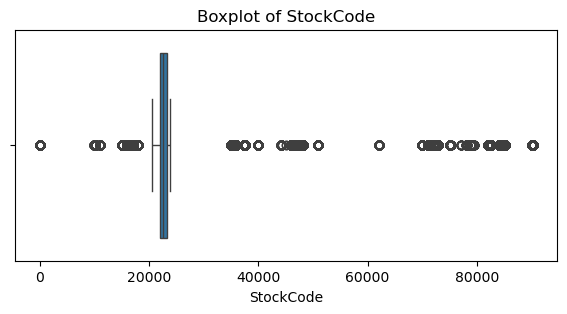

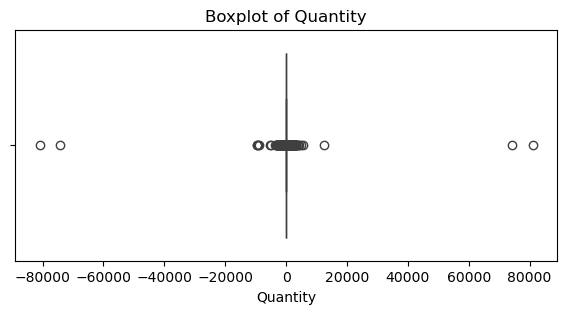

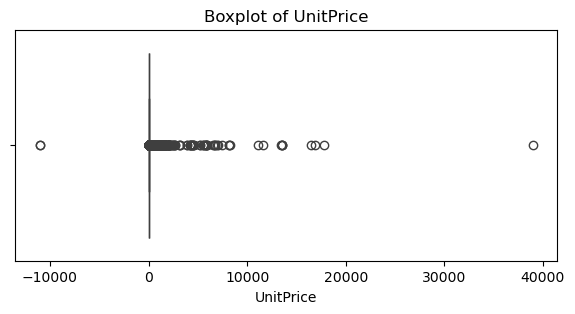

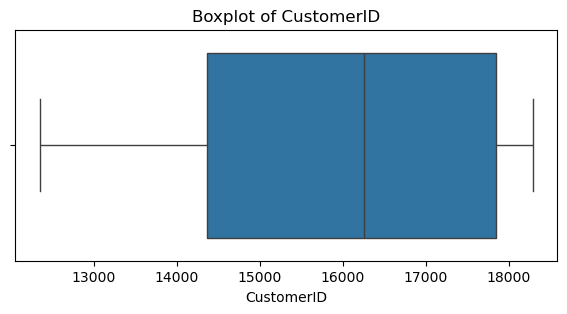

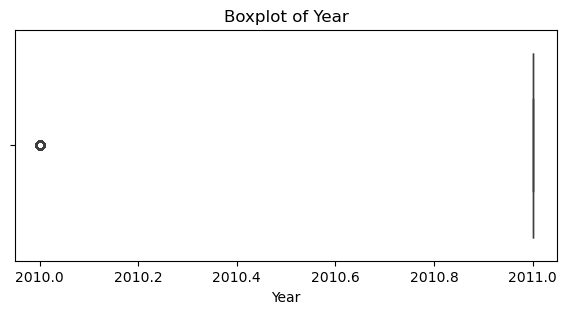

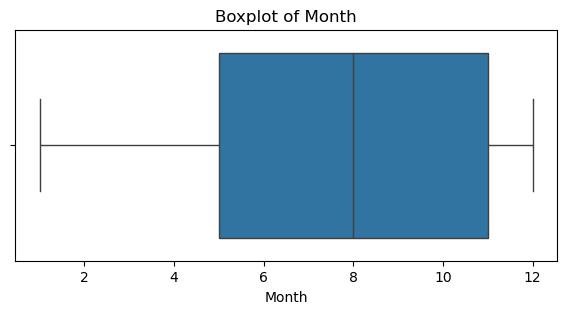

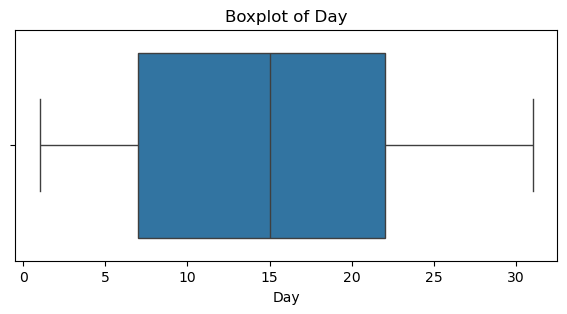

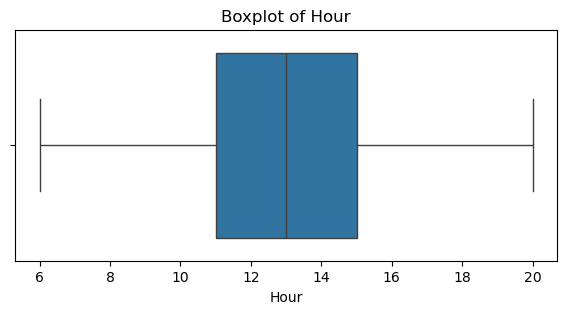

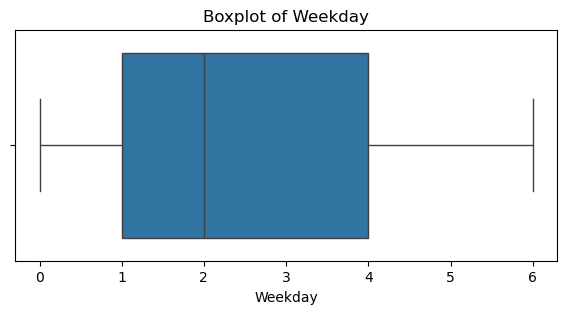

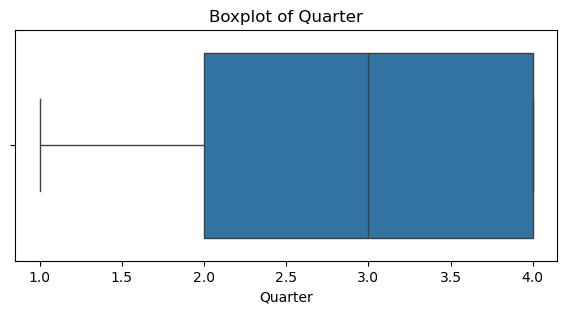

In [229]:
for col in num_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

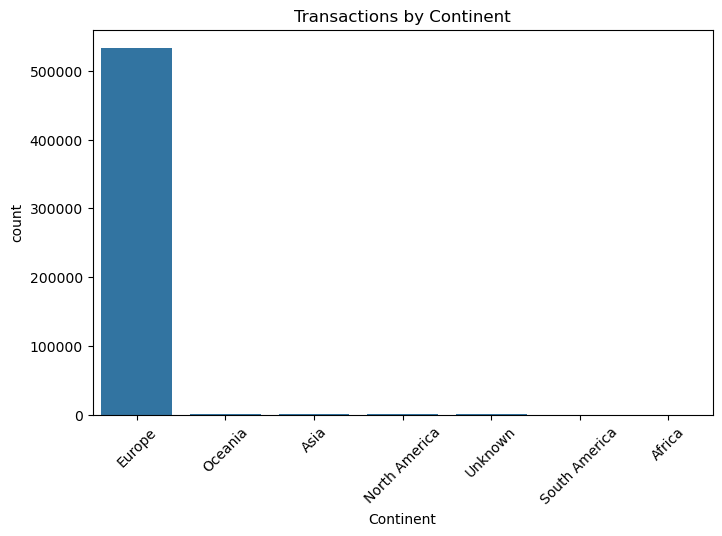

In [230]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Continent")
plt.title("Transactions by Continent")
plt.xticks(rotation=45)
plt.show()

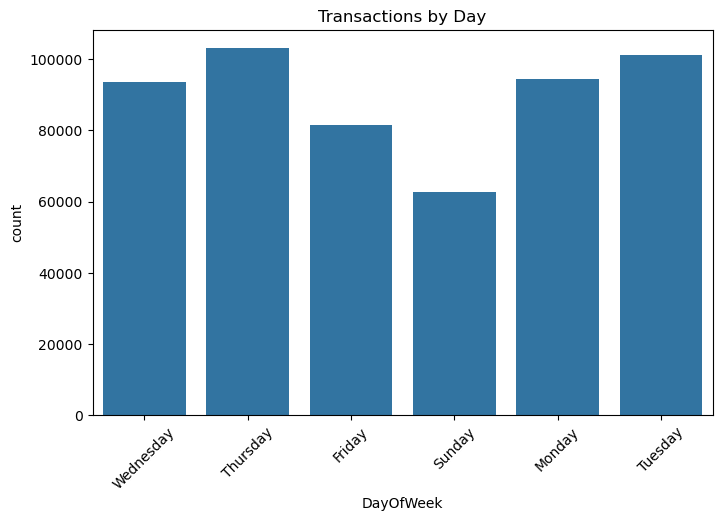

In [231]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="DayOfWeek")
plt.title("Transactions by Day")
plt.xticks(rotation=45)
plt.show()

In [232]:
#adding sale calumn
df["Sales"] = df["Quantity"] * df["UnitPrice"]

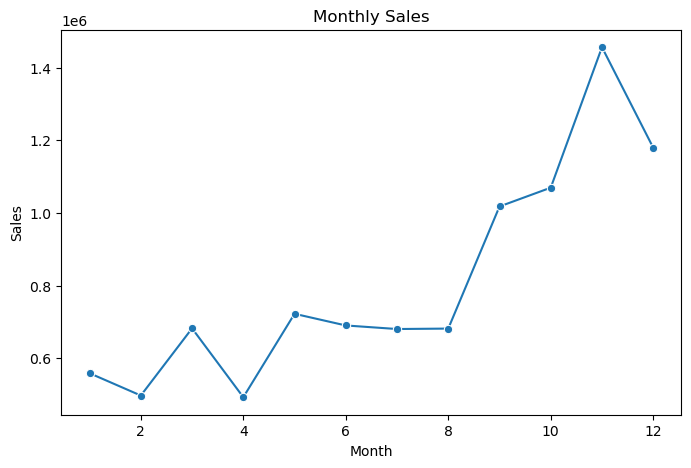

In [233]:
monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=monthly_sales, x="Month", y="Sales", marker="o")
plt.title("Monthly Sales")
plt.show()

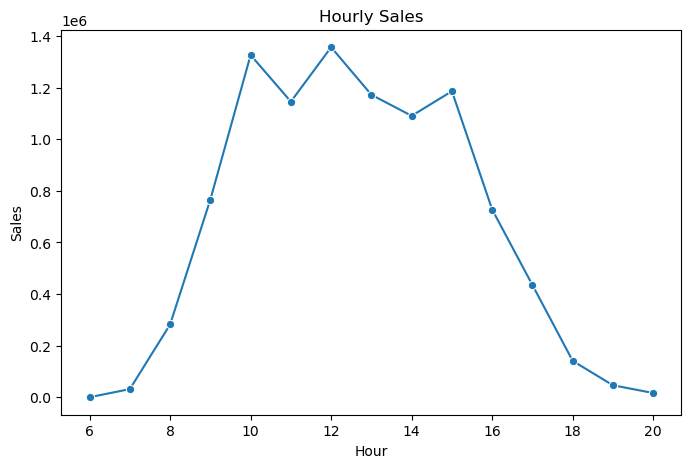

In [234]:
hourly_sales = df.groupby("Hour")["Sales"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=hourly_sales, x="Hour", y="Sales", marker="o")
plt.title("Hourly Sales")
plt.show()

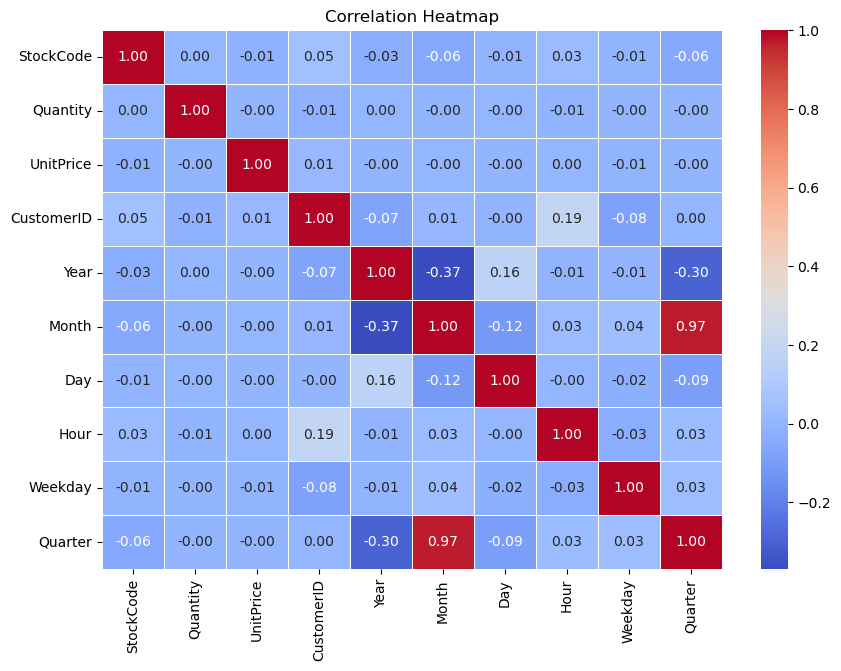

In [235]:
plt.figure(figsize=(10,7))

corr = df[num_cols].corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [236]:
# Create Sales column
df["Sales"] = df["Quantity"] * df["UnitPrice"]

# Weekly sales
weekly_sales = df.groupby("Weekday", as_index=False)["Sales"].sum()

weekly_sales

,Weekday,Sales
0,0,1584895.301
1,1,1965703.611
2,2,1730088.430
3,3,2108701.530
4,4,1537958.621
5,6,798659.461


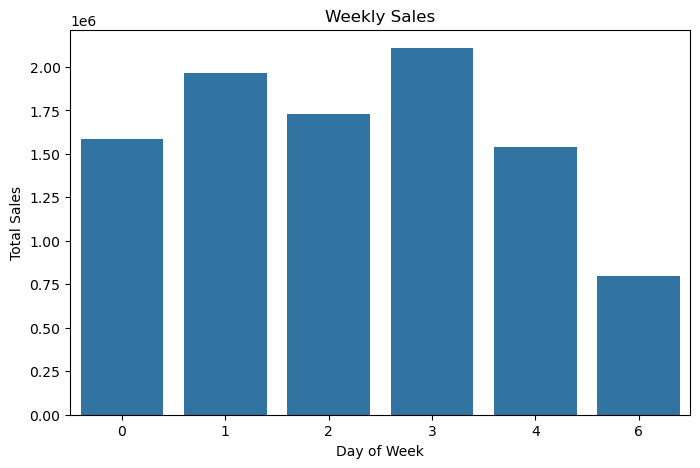

In [237]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=weekly_sales,
    x="Weekday",
    y="Sales"
)

plt.title("Weekly Sales")
plt.xlabel("Day of Week")
plt.ylabel("Total Sales")
plt.show()

In [238]:
##see data again
df.sample(5)

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID,Continent,Year,Month,Day,Hour,DayOfWeek,Weekday,Quarter,Sales
331133,565971,22091.0,7,0.39,13571.0,Europe,2011,9,8,11,Thursday,3,3,2.73
374997,569414,23205.0,11,2.46,17841.0,Europe,2011,10,4,10,Tuesday,1,4,27.06
225306,C556656,22832.0,-1,10.75,13148.0,Europe,2011,6,13,16,Monday,0,2,-10.75
313312,564483,21289.0,16,1.25,14050.0,Europe,2011,8,25,13,Thursday,3,3,20.00
386426,570234,23399.0,5,0.85,17790.0,Europe,2011,10,9,14,Sunday,6,4,4.25


In [239]:
col_num=['StockCode',
 'Quantity',
 'UnitPrice','Year']

df[col_num]

,StockCode,Quantity,UnitPrice,Year
0,85123.0,6,2.55,2010
1,71053.0,6,3.39,2010
2,84406.0,8,2.75,2010
3,84029.0,6,3.39,2010
4,84029.0,6,3.39,2010
...,...,...,...,...
541904,22613.0,12,0.85,2011
541905,22899.0,6,2.10,2011
541906,23254.0,4,4.15,2011
541907,23255.0,4,4.15,2011


In [240]:
col_num = ['StockCode', 'Quantity', 'UnitPrice']

for col in col_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

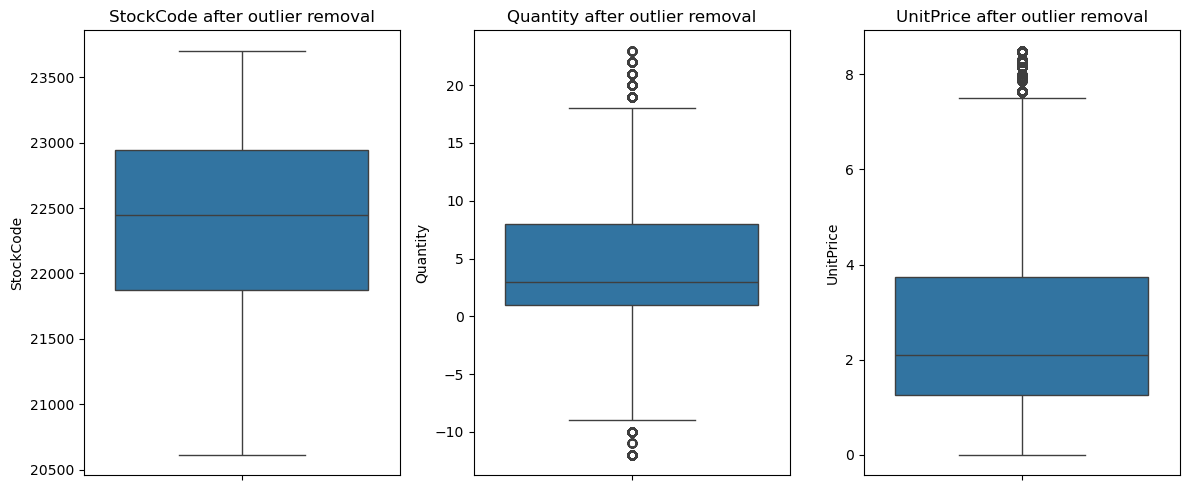

In [241]:
# Plot after removing outliers
plt.figure(figsize=(12, 5))

for i, col in enumerate(col_num, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'{col} after outlier removal')

plt.tight_layout()
plt.show()

In [242]:
df_data=df.copy()

In [243]:
continuous_cols = ['Quantity', 'UnitPrice', 'Sales']

pt = PowerTransformer(method='yeo-johnson')

df[continuous_cols] = pt.fit_transform(df[continuous_cols])

In [244]:
df.sample(5)

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID,Continent,Year,Month,Day,Hour,DayOfWeek,Weekday,Quarter,Sales
313631,564526,23298.0,0.329575,1.164355,15805.0,Europe,2011,8,25,14,Thursday,3,3,1.568035
152473,549596,21559.0,0.329575,0.191543,14339.0,Europe,2011,4,11,11,Monday,0,2,0.458726
130361,547485,21791.0,-0.835164,-0.771450,17019.0,Europe,2011,3,23,11,Wednesday,2,1,-0.848269
416832,572561,22584.0,0.329575,0.191543,13652.0,Europe,2011,10,25,8,Tuesday,1,4,0.458726
295704,562812,23109.0,2.472223,0.372553,13217.0,Europe,2011,8,9,15,Tuesday,1,3,3.117459


In [245]:
df["Quantity"].skew()

np.float64(-0.07207829877749009)

In [246]:
day_map = {
    "Monday": 0,
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 5,
    "Sunday": 6
}

df["DayOfWeek"] = df["DayOfWeek"].map(day_map)

In [247]:
df = pd.get_dummies(df, columns=["Continent"], dtype=int,drop_first=True)

df.head()

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID,Year,Month,Day,Hour,DayOfWeek,Weekday,Quarter,Sales,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America,Continent_Unknown
5,536365,22752.0,-0.570290,1.798858,17850.0,2010,12,1,8,2,2,4,0.458726,0,1,0,0,0,0
6,536365,21730.0,0.329575,0.939327,17850.0,2010,12,1,8,2,2,4,1.256658,0,1,0,0,0,0
7,536366,22633.0,0.329575,-0.259368,17850.0,2010,12,1,8,2,2,4,0.105602,0,1,0,0,0,0
8,536366,22632.0,0.329575,-0.259368,17850.0,2010,12,1,8,2,2,4,0.105602,0,1,0,0,0,0
10,536367,22745.0,0.329575,-0.083982,13047.0,2010,12,1,8,2,2,4,0.233907,0,1,0,0,0,0


In [248]:
df["InvoiceNo"].unique()

array([536365, 536366, 536367, ..., 581585, 581586, 581587],
      shape=(20408,), dtype=object)

In [249]:
print(df[df["InvoiceNo"] == "C536379"])

Empty DataFrame
Columns: [InvoiceNo, StockCode, Quantity, UnitPrice, CustomerID, Year, Month, Day, Hour, DayOfWeek, Weekday, Quarter, Sales, Continent_Asia, Continent_Europe, Continent_North America, Continent_Oceania, Continent_South America, Continent_Unknown]
Index: []


In [250]:
list1 = []

for data in df["InvoiceNo"].astype(str):
    if data.startswith("C"):
        list1.append(1)
    else:
        list1.append(0)

df["IsCancelled"] = list1

In [251]:
df.drop(columns=["InvoiceNo"],inplace=True)

In [252]:
df.head()

,StockCode,Quantity,UnitPrice,CustomerID,Year,Month,Day,Hour,DayOfWeek,Weekday,Quarter,Sales,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America,Continent_Unknown,IsCancelled
5,22752.0,-0.570290,1.798858,17850.0,2010,12,1,8,2,2,4,0.458726,0,1,0,0,0,0,0
6,21730.0,0.329575,0.939327,17850.0,2010,12,1,8,2,2,4,1.256658,0,1,0,0,0,0,0
7,22633.0,0.329575,-0.259368,17850.0,2010,12,1,8,2,2,4,0.105602,0,1,0,0,0,0,0
8,22632.0,0.329575,-0.259368,17850.0,2010,12,1,8,2,2,4,0.105602,0,1,0,0,0,0,0
10,22745.0,0.329575,-0.083982,13047.0,2010,12,1,8,2,2,4,0.233907,0,1,0,0,0,0,0


In [253]:
##stockcode unique
df["StockCode"].unique()

array([22752., 21730., 22633., ..., 22509., 22165., 23143.], shape=(2289,))

In [254]:
##to much unique not need for cluster
df.drop(columns=["StockCode"],inplace=True)

In [255]:
##customerId unique
df["CustomerID"].unique()

array([17850., 13047., 12583., ..., 15520., 14569., 12713.], shape=(4162,))

In [256]:
##to much unique not need for cluster
df.drop(columns=["CustomerID"],inplace=True)

In [257]:
df.head()

,Quantity,UnitPrice,Year,Month,Day,Hour,DayOfWeek,Weekday,Quarter,Sales,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America,Continent_Unknown,IsCancelled
5,-0.570290,1.798858,2010,12,1,8,2,2,4,0.458726,0,1,0,0,0,0,0
6,0.329575,0.939327,2010,12,1,8,2,2,4,1.256658,0,1,0,0,0,0,0
7,0.329575,-0.259368,2010,12,1,8,2,2,4,0.105602,0,1,0,0,0,0,0
8,0.329575,-0.259368,2010,12,1,8,2,2,4,0.105602,0,1,0,0,0,0,0
10,0.329575,-0.083982,2010,12,1,8,2,2,4,0.233907,0,1,0,0,0,0,0


In [258]:
##unique
df["UnitPrice"].unique()

array([ 1.79885844,  0.93932749, -0.25936799, -0.08398155,  0.75455959,
       -0.41396078,  1.16435509,  1.43459254,  1.85394501, -1.21758682,
        0.40246716, -0.96998698, -0.18701427,  0.19154294, -0.77145024,
       -0.3819125 , -0.58368431,  0.83122731,  1.6183083 ,  1.66059632,
        1.94924713, -1.8540944 ,  0.63175228,  0.58852434,  1.07214379,
       -1.48802478, -2.09510256, -1.09557501, -1.63891325,  0.54405103,
       -0.54840025,  0.01306927,  1.52953948,  0.16884433, -0.40589295,
       -1.83669209,  1.79322021,  0.92536087,  0.41721442,  1.42472763,
        0.59290213, -0.74199792,  1.94422634, -1.26869452,  1.19673709,
        1.62259745, -1.23023489, -2.76129488, -0.9810581 ,  1.31668747,
        0.60596141, -2.45987052,  1.38200064,  1.30594901,  0.78569682,
       -0.06411338,  1.58569755, -1.38897012, -1.24296817, -0.78137566,
        0.39752062, -0.09065711, -0.42206631,  0.18589801,  1.77042244,
        1.1220555 ,  0.16311971, -0.07070987, -1.34803099, -0.55

In [259]:
X = df.copy()

In [260]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [261]:
X_scaled

array([[-0.57028971,  1.79885844, -3.53837571, ..., -0.00741764,
        -0.02907311, -0.12393405],
       [ 0.32957467,  0.93932749, -3.53837571, ..., -0.00741764,
        -0.02907311, -0.12393405],
       [ 0.32957467, -0.25936799, -3.53837571, ..., -0.00741764,
        -0.02907311, -0.12393405],
       ...,
       [-0.09761404,  0.90416068,  0.28261555, ..., -0.00741764,
        -0.02907311, -0.12393405],
       [-0.09761404,  0.90416068,  0.28261555, ..., -0.00741764,
        -0.02907311, -0.12393405],
       [-0.32662765,  1.16435509,  0.28261555, ..., -0.00741764,
        -0.02907311, -0.12393405]], shape=(363515, 17))

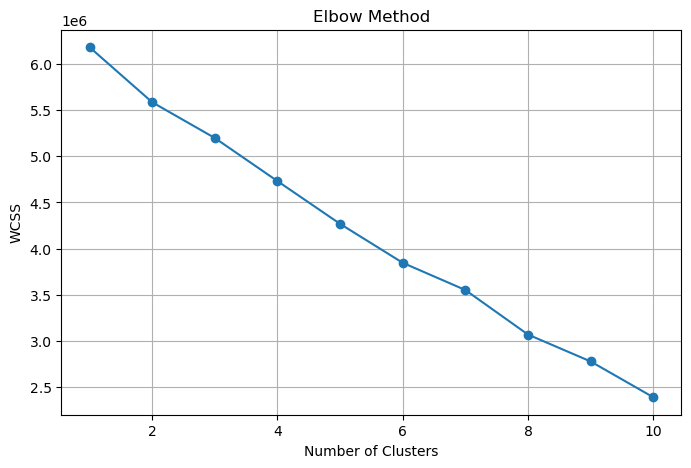

In [262]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [263]:
silhouette_scores = []
cluster = []

for k in range(2, 10):
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        init="random",
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)   # Store the labels
    score = silhouette_score(
    X_scaled,
    labels,
    sample_size=min(4000, len(X_scaled)),
    random_state=42
)

    silhouette_scores.append(score)
    cluster.append(k)

print(silhouette_scores)  

[0.17211481918942423, 0.1805885848953451, 0.13856775598188903, 0.17697383861277297, 0.1762037210588507, 0.18523295301526588, 0.17103465154981287, 0.15637160965092894]


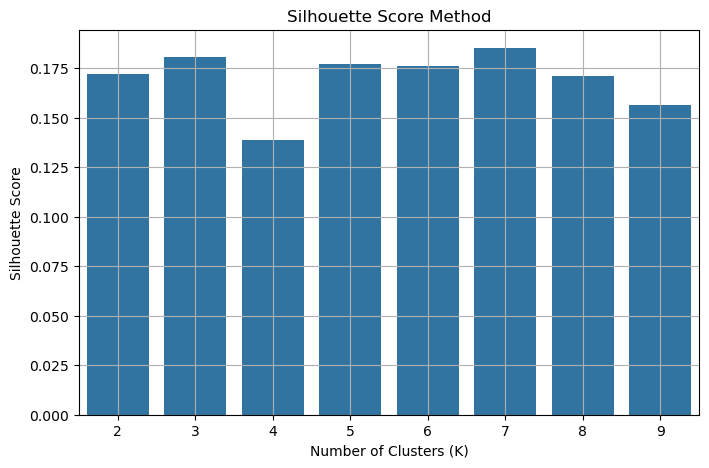

In [264]:
plt.figure(figsize=(8, 5))
sns.barplot(x=cluster, y=silhouette_scores)
plt.title("Silhouette Score Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [265]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [266]:
df["Cluster"].value_counts()

Cluster
1    215323
0    147580
2       612
Name: count, dtype: int64

In [267]:
df["Cluster"]=df["Cluster"]+1
df["Cluster"]=df["Cluster"].astype("str")
df["Cluster"]="cluster"+" "+df["Cluster"]

In [268]:
from sklearn.decomposition import PCA
# PCA to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "Cluster": df["Cluster"].astype(str)
})


<Axes: xlabel='PCA1', ylabel='PCA2'>

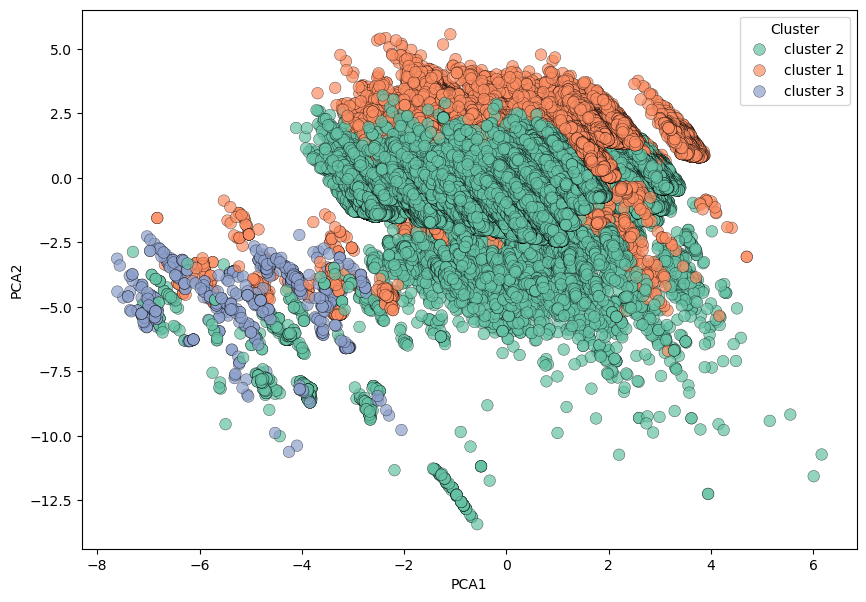

In [269]:
# Plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    s=70,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.3
)

In [270]:
new_data = [[20000,50,2026,1,26,5,2,  2,4,500000,1 ,0 , 0 , 0 , 0,  0,  0]]

In [271]:
new_data_scaled = scaler.transform(new_data)

prediction = kmeans.predict(new_data_scaled)

print("Predicted Cluster:", prediction)

Predicted Cluster: [2]


In [272]:
df.head()

,Quantity,UnitPrice,Year,Month,Day,Hour,DayOfWeek,Weekday,Quarter,Sales,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America,Continent_Unknown,IsCancelled,Cluster
5,-0.570290,1.798858,2010,12,1,8,2,2,4,0.458726,0,1,0,0,0,0,0,cluster 2
6,0.329575,0.939327,2010,12,1,8,2,2,4,1.256658,0,1,0,0,0,0,0,cluster 2
7,0.329575,-0.259368,2010,12,1,8,2,2,4,0.105602,0,1,0,0,0,0,0,cluster 2
8,0.329575,-0.259368,2010,12,1,8,2,2,4,0.105602,0,1,0,0,0,0,0,cluster 2
10,0.329575,-0.083982,2010,12,1,8,2,2,4,0.233907,0,1,0,0,0,0,0,cluster 2


In [280]:
df_data["cluster"]=df["Cluster"]
df_data.head()

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID,Continent,Year,Month,Day,Hour,DayOfWeek,Weekday,Quarter,Sales,cluster
5,536365,22752.0,2,7.65,17850.0,Europe,2010,12,1,8,Wednesday,2,4,15.3,cluster 2
6,536365,21730.0,6,4.25,17850.0,Europe,2010,12,1,8,Wednesday,2,4,25.5,cluster 2
7,536366,22633.0,6,1.85,17850.0,Europe,2010,12,1,8,Wednesday,2,4,11.1,cluster 2
8,536366,22632.0,6,1.85,17850.0,Europe,2010,12,1,8,Wednesday,2,4,11.1,cluster 2
10,536367,22745.0,6,2.10,13047.0,Europe,2010,12,1,8,Wednesday,2,4,12.6,cluster 2


In [281]:
df_data.groupby("cluster")[["Quantity", "UnitPrice","Sales"]].mean()

,Quantity,UnitPrice,Sales
cluster,,,
cluster 1,5.072083,2.683351,10.876876
cluster 2,4.736020,2.829183,10.677473
cluster 3,7.736928,3.047337,21.675882


----

In [284]:
cluster_map = {
    "cluster 1": "Medium-Spend Buyers",
    "cluster 2": "Lower-Spend Buyers",
    "cluster 3": "Premium Customers"
}

df["CustomerSegment"] = df["Cluster"].map(cluster_map)

In [286]:
df.head()

,Quantity,UnitPrice,Year,Month,Day,Hour,DayOfWeek,Weekday,Quarter,Sales,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America,Continent_Unknown,IsCancelled,Cluster,CustomerSegment
5,-0.570290,1.798858,2010,12,1,8,2,2,4,0.458726,0,1,0,0,0,0,0,cluster 2,Lower-Spend Buyers
6,0.329575,0.939327,2010,12,1,8,2,2,4,1.256658,0,1,0,0,0,0,0,cluster 2,Lower-Spend Buyers
7,0.329575,-0.259368,2010,12,1,8,2,2,4,0.105602,0,1,0,0,0,0,0,cluster 2,Lower-Spend Buyers
8,0.329575,-0.259368,2010,12,1,8,2,2,4,0.105602,0,1,0,0,0,0,0,cluster 2,Lower-Spend Buyers
10,0.329575,-0.083982,2010,12,1,8,2,2,4,0.233907,0,1,0,0,0,0,0,cluster 2,Lower-Spend Buyers
